# Train People Counting

Notebook ini training YOLO26m buat deteksi orang doang (1 kelas: `person`). Tujuan akhirnya: hitung berapa orang di scene CCTV.

**Dataset asal:** `research/datasets/raw/people_counting/` — tapi raw-nya punya 53 kelas (variasi nama: Pedestrian, Persona, Pessoa, dst.). Kita bakal bikin dulu versi processed yang cuma punya 1 kelas: `person`.

**Output:** `best.pt` di `research/runs/detect/people_counting_yolo26m/weights/`.

## Alur

1. Setup
2. Bikin dataset processed (filter + remap ke 1 kelas)
3. Cek distribusi
4. Training
5. Load run terakhir
6. Evaluasi (counting metrics: MAE, RMSE, exact match, dll.)
7. Visualisasi (training curves, scatter, error distribution, per-density, sample prediksi)


In [1]:
%matplotlib inline

from __future__ import annotations

import contextlib
import os
import math
import random
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from ultralytics import YOLO

NOTEBOOK_DIR = Path.cwd()
RESEARCH_DIR = NOTEBOOK_DIR.parents[1]
AI_DIR       = NOTEBOOK_DIR.parents[2]

RAW_DATASET_DIR  = RESEARCH_DIR / "datasets" / "raw" / "people_counting"
PROC_DATASET_DIR = RESEARCH_DIR / "datasets" / "processed" / "people_counting_single_class"
DATA_YAML        = PROC_DATASET_DIR / "data.yaml"
BASE_MODEL       = AI_DIR / "models" / "yolo26m.pt"

RUNS_DIR      = RESEARCH_DIR / "runs" / "detect"
ARTIFACTS_DIR = RESEARCH_DIR / "artifacts" / "people_counting"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = "people_counting_yolo26m"
SEED     = 42

PERSON_NAME_HINTS = {
    "person", "people", "pedestrian", "pedestrians",
    "persona", "pessoa", "persons",
}

for p in [RAW_DATASET_DIR, BASE_MODEL]:
    if not p.exists():
        raise FileNotFoundError(f"Nggak ketemu: {p}")
print("Raw dataset:", RAW_DATASET_DIR)
print("Processed dataset (target):", PROC_DATASET_DIR)
print("Base model:", BASE_MODEL)

Raw dataset: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\raw\people_counting
Processed dataset (target): c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\processed\people_counting_single_class
Base model: c:\Users\istd.magang125\Documents\cctv-insight\ai\models\yolo26m.pt


## Bikin Dataset Single-Class

Filter label dari raw dataset: cuma simpan kelas person-like (Pedestrian, Persona, dst.), terus remap semuanya jadi `0=person`.

Set `OVERWRITE_PROC = True` kalau mau rebuild dari nol. Default `False` biar nggak rebuild tiap re-run notebook (operasi mahal).


In [2]:
OVERWRITE_PROC = False


def _resolve_person_source_ids(raw_cfg: dict) -> set[int]:
    names = raw_cfg.get("names", [])
    matched = {
        i for i, n in enumerate(names)
        if str(n).strip().lower() in PERSON_NAME_HINTS
    }
    if not matched:
        raise ValueError("Nggak nemu kelas person-like di raw data.yaml")
    return matched


def _list_images(image_dir: Path) -> list[Path]:
    images: list[Path] = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        images.extend(sorted(image_dir.glob(ext)))
    return images


def build_single_class_dataset() -> None:
    if DATA_YAML.exists() and not OVERWRITE_PROC:
        print("Processed dataset udah ada, skip rebuild:", DATA_YAML)
        return

    if PROC_DATASET_DIR.exists() and OVERWRITE_PROC:
        shutil.rmtree(PROC_DATASET_DIR)

    raw_cfg = yaml.safe_load((RAW_DATASET_DIR / "data.yaml").read_text(encoding="utf-8"))
    person_ids = _resolve_person_source_ids(raw_cfg)
    print("Person source class IDs:", sorted(person_ids))

    stats: dict[str, int] = {}
    for split in ("train", "valid", "test"):
        img_dir = RAW_DATASET_DIR / split / "images"
        lbl_dir = RAW_DATASET_DIR / split / "labels"
        if not img_dir.exists():
            continue

        out_img = PROC_DATASET_DIR / split / "images"
        out_lbl = PROC_DATASET_DIR / split / "labels"
        out_img.mkdir(parents=True, exist_ok=True)
        out_lbl.mkdir(parents=True, exist_ok=True)

        added = 0
        for img_path in _list_images(img_dir):
            lbl_src = lbl_dir / f"{img_path.stem}.txt"
            if not lbl_src.exists():
                continue
            lines: list[str] = []
            for raw in lbl_src.read_text(encoding="utf-8").splitlines():
                raw = raw.strip()
                if not raw:
                    continue
                parts = raw.split()
                if int(parts[0]) not in person_ids:
                    continue
                lines.append(" ".join(["0"] + parts[1:]))
            if not lines:
                continue
            shutil.copy2(img_path, out_img / img_path.name)
            (out_lbl / f"{img_path.stem}.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")
            added += 1
        stats[split] = added
        print(f"  {split}: {added} images")

    cfg = {
        "path":  str(PROC_DATASET_DIR.resolve()),
        "train": "train/images",
        "val":   "valid/images",
        "test":  "test/images",
        "nc":    1,
        "names": ["person"],
    }
    DATA_YAML.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding="utf-8")
    print("Dataset jadi:", DATA_YAML)


build_single_class_dataset()

Processed dataset udah ada, skip rebuild: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\processed\people_counting_single_class\data.yaml


## Cek Distribusi

Jumlah image dan jumlah person bbox per split. `avg_per_image` = rata-rata orang per image — ini ngasih gambaran density dataset (dataset zoom ke few-people atau crowd).


In [3]:
def _list_images(image_dir: Path) -> list[Path]:
    images: list[Path] = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        images.extend(sorted(image_dir.glob(ext)))
    return images


def count_persons(split: str) -> tuple[int, int]:
    img_dir = PROC_DATASET_DIR / split / "images"
    lbl_dir = PROC_DATASET_DIR / split / "labels"
    if not img_dir.exists():
        return 0, 0
    n_images = len(_list_images(img_dir))
    n_persons = 0
    for lbl in lbl_dir.glob("*.txt"):
        n_persons += sum(1 for line in lbl.read_text().splitlines() if line.strip())
    return n_images, n_persons


rows = []
for split in ("train", "valid", "test"):
    n_img, n_per = count_persons(split)
    rows.append({
        "split": split,
        "images": n_img,
        "persons": n_per,
        "avg_per_image": round(n_per / n_img, 2) if n_img else 0,
    })
print(pd.DataFrame(rows).to_string(index=False))

split  images  persons  avg_per_image
train   12667    78629           6.21
valid    1170    10040           8.58
 test     716     2679           3.74


## Training

Set `RUN_TRAINING = True` kalau mau training ulang. Default 50 epoch.


In [ ]:
RUN_TRAINING = False

TRAIN_CFG = {
    "epochs": 50,
    "imgsz": 640,
    "batch": 8,
    "workers": 4,
    "patience": 20,
    "seed": SEED,
    "project": str(RUNS_DIR),
    "name": RUN_NAME,
}


@contextlib.contextmanager
def _cwd(path):
    prev = os.getcwd()
    os.chdir(str(path))
    try:
        yield
    finally:
        os.chdir(prev)


if RUN_TRAINING:
    with _cwd(AI_DIR / "models"):
        model = YOLO(str(BASE_MODEL))
        result = model.train(data=str(DATA_YAML), **TRAIN_CFG)
    print("Training kelar:", result.save_dir)
else:
    print("Training di-skip. Set RUN_TRAINING=True kalau mau training ulang.")

New https://pypi.org/project/ultralytics/8.4.43 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.38  Python-3.14.3 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\processed\people_counting_single_class\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=

## Load Run Terakhir


In [5]:
def find_latest_run(prefix: str) -> Path:
    candidates = [
        d for d in RUNS_DIR.glob(f"{prefix}*")
        if d.is_dir() and (d / "weights" / "best.pt").exists()
    ]
    if not candidates:
        raise FileNotFoundError(f"Belum ada run dengan prefix '{prefix}' di {RUNS_DIR}")
    return max(candidates, key=lambda d: d.stat().st_mtime)


run_dir     = find_latest_run(RUN_NAME)
best_pt     = run_dir / "weights" / "best.pt"
results_csv = run_dir / "results.csv"
eval_model  = YOLO(str(best_pt))

print("Run dir:", run_dir)
print("Best weights:", best_pt)
print("Kelas:", eval_model.names)

Run dir: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\runs\detect\people_counting_yolo26m2
Best weights: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\runs\detect\people_counting_yolo26m2\weights\best.pt
Kelas: {0: 'person'}


## Evaluasi: Counting Metrics

People counting itu tugas regresi count, bukan detection murni. Yang penting bukan posisi bbox, tapi **berapa orang totalnya**. Makanya metric-nya beda dari face_mask:

- **MAE** — rata-rata selisih hitungan per image. Lebih kecil lebih bagus.
- **RMSE** — kasih penalty besar buat outlier (crowd padat). Kalau jauh lebih tinggi dari MAE, ada outlier serius.
- **Exact match** — % image yang prediksi-nya tepat.
- **Within-1** — % image yang selisih ≤ 1 orang. Tolerance operational.
- **Bias** — rata-rata error signed. Negatif = sistematis undercount, positif = overcount.

Default eval pakai 500 image dari split test+valid. Set `MAX_IMAGES = None` kalau mau full.


In [6]:
MAX_IMAGES  = 500
COUNT_CONF  = 0.25
COUNT_IMGSZ = 640


def collect_eval_images() -> list[Path]:
    images: list[Path] = []
    for split in ("test", "valid"):
        d = PROC_DATASET_DIR / split / "images"
        if not d.exists():
            continue
        images.extend(_list_images(d))
    return images


def count_gt(label_path: Path) -> int:
    if not label_path.exists():
        return 0
    return sum(1 for line in label_path.read_text().splitlines() if line.strip())


def count_pred(image_path: Path) -> int:
    r = eval_model.predict(str(image_path), conf=COUNT_CONF, imgsz=COUNT_IMGSZ, verbose=False)
    if not r or r[0].boxes is None:
        return 0
    return len(r[0].boxes)


images = collect_eval_images()
if MAX_IMAGES is not None and len(images) > MAX_IMAGES:
    images = random.Random(SEED).sample(images, MAX_IMAGES)
print("Eval images:", len(images))

rows = []
for i, img_path in enumerate(images, start=1):
    gt = count_gt(img_path.parent.parent / "labels" / f"{img_path.stem}.txt")
    pred = count_pred(img_path)
    err = pred - gt
    rows.append({"gt": gt, "pred": pred, "err": err, "abs_err": abs(err)})
    if i % 100 == 0:
        print(f"  {i}/{len(images)}")

count_df = pd.DataFrame(rows)
count_metrics = {
    "samples":     int(len(count_df)),
    "MAE":         round(float(count_df["abs_err"].mean()), 3),
    "RMSE":        round(float(((count_df["err"] ** 2).mean()) ** 0.5), 3),
    "exact_match": round(float((count_df["err"] == 0).mean()), 3),
    "within_1":    round(float((count_df["abs_err"] <= 1).mean()), 3),
    "bias":        round(float(count_df["err"].mean()), 3),
}
print()
print("Metrik counting:")
print(pd.DataFrame([count_metrics]).to_string(index=False))

Eval images: 500
  100/500
  200/500
  300/500
  400/500
  500/500

Metrik counting:
 samples   MAE  RMSE  exact_match  within_1   bias
     500 1.768 8.744        0.636     0.834 -0.752


## Visualisasi

Yang penting buat counting:

1. **Training curves** — convergence check.
2. **Scatter pred vs gt** — kalau titik di garis merah = prediksi tepat. Yang di bawah = undercount, di atas = overcount.
3. **Error distribution** — bentuk distribusi error. Center di 0 = bagus.
4. **Cumulative accuracy** — % image yang error-nya ≤ k. Trade-off strict (k=0) vs lenient (k=5).
5. **Per-density breakdown** — MAE per kelompok density. Model biasanya OK di sepi, drop di crowd padat.
6. **Sample prediksi** — sanity check.


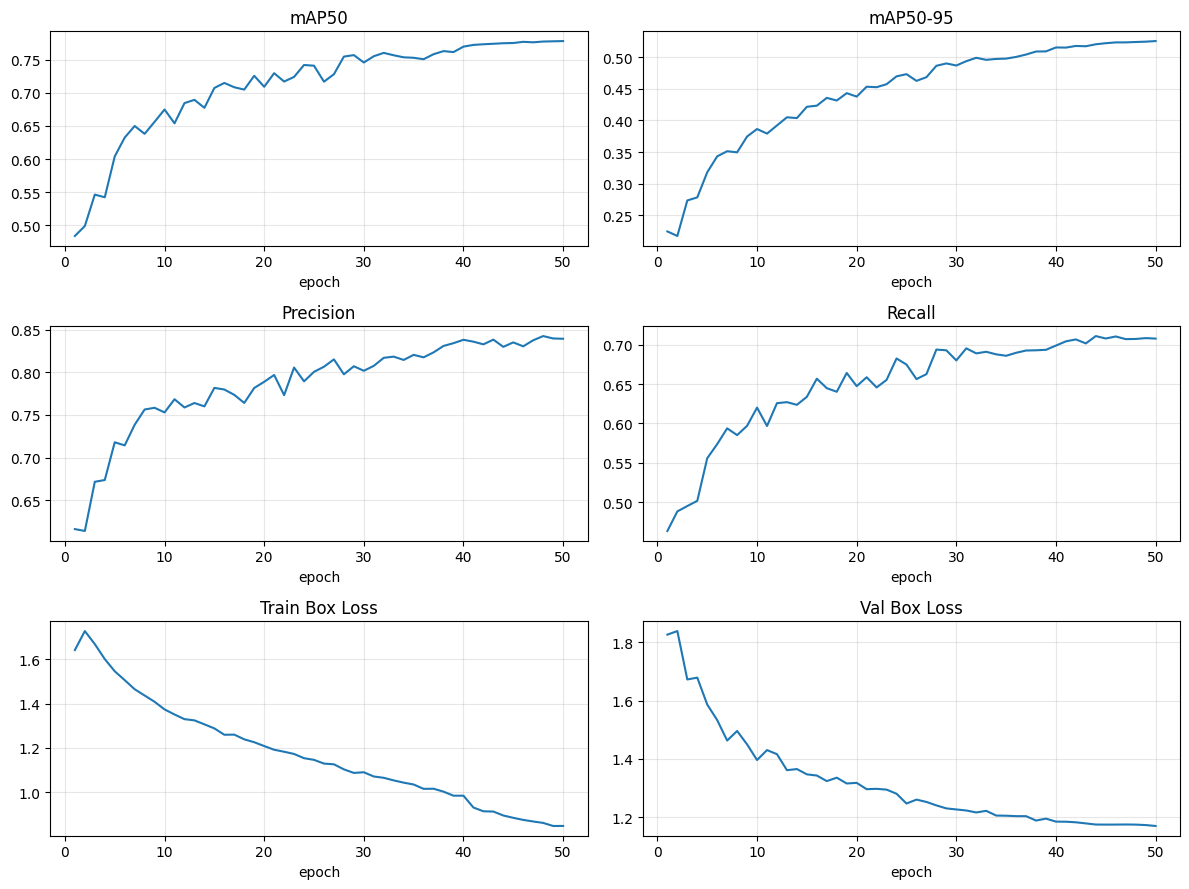

In [7]:
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

curves = [
    ("metrics/mAP50(B)",     "mAP50"),
    ("metrics/mAP50-95(B)",  "mAP50-95"),
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)",    "Recall"),
    ("train/box_loss",       "Train Box Loss"),
    ("val/box_loss",         "Val Box Loss"),
]
available = [(c, label) for c, label in curves if c in df.columns]
rows_n = (len(available) + 1) // 2
fig, axes = plt.subplots(rows_n, 2, figsize=(12, 3 * rows_n))
axes = axes.flatten()
for ax, (col, label) in zip(axes, available):
    ax.plot(df["epoch"], df[col])
    ax.set_title(label)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
for ax in axes[len(available):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

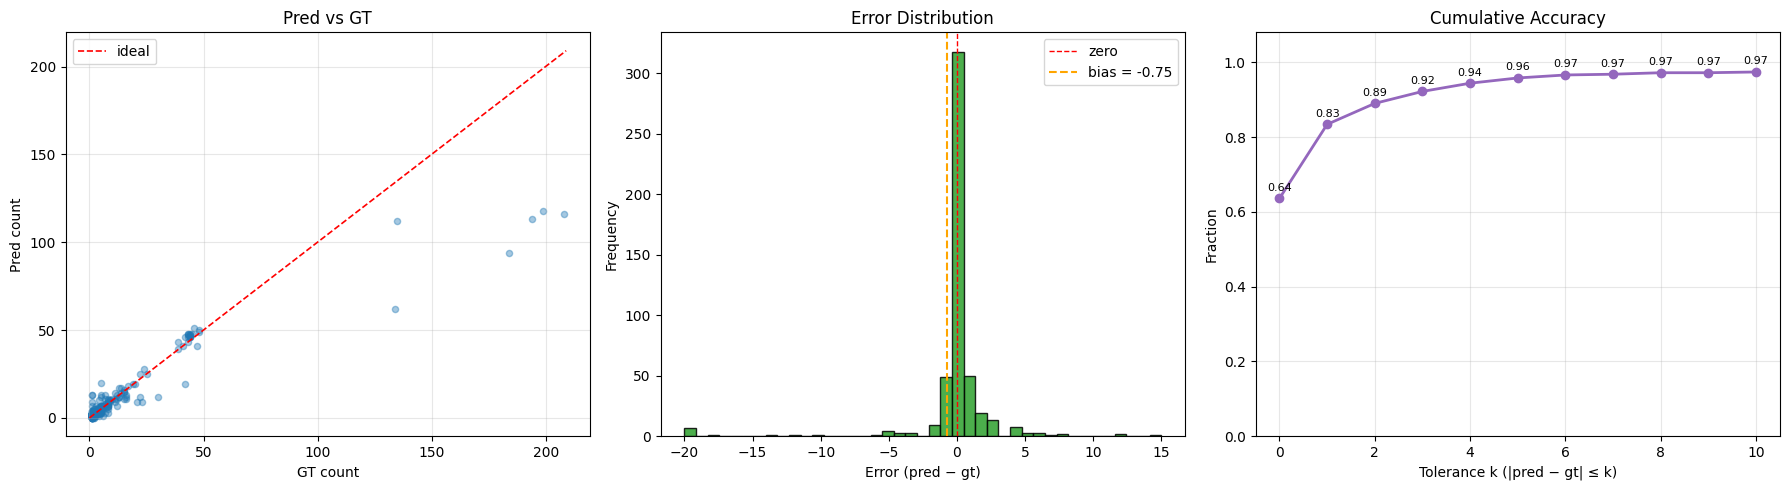

Per-density breakdown:
           n    MAE   bias
density                   
1-5      415   0.52   0.24
6-10      30   1.63   0.03
11-20     21   1.90  -0.67
21-50     28   5.07  -0.86
50+        6  73.17 -73.17


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

max_v = int(max(count_df["gt"].max(), count_df["pred"].max())) + 1
axes[0].scatter(count_df["gt"], count_df["pred"], alpha=0.4, s=20, color="#1f77b4")
axes[0].plot([0, max_v], [0, max_v], "r--", linewidth=1.2, label="ideal")
axes[0].set_xlabel("GT count")
axes[0].set_ylabel("Pred count")
axes[0].set_title("Pred vs GT")
axes[0].legend()
axes[0].grid(alpha=0.3)

err_clip = count_df["err"].clip(-20, 20)
axes[1].hist(err_clip, bins=41, color="#2ca02c", edgecolor="black", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1, label="zero")
axes[1].axvline(count_metrics["bias"], color="orange", linestyle="--",
                label=f"bias = {count_metrics['bias']:.2f}")
axes[1].set_xlabel("Error (pred − gt)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Error Distribution")
axes[1].legend()

ks = list(range(0, 11))
cum = [(count_df["abs_err"] <= k).mean() for k in ks]
axes[2].plot(ks, cum, marker="o", color="#9467bd", linewidth=2)
for k, v in zip(ks, cum):
    axes[2].text(k, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
axes[2].set_ylim(0, 1.08)
axes[2].set_xlabel("Tolerance k (|pred − gt| ≤ k)")
axes[2].set_ylabel("Fraction")
axes[2].set_title("Cumulative Accuracy")
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

bins = [-1, 0, 5, 10, 20, 50, max(int(count_df["gt"].max()) + 1, 51)]
labels = ["0", "1-5", "6-10", "11-20", "21-50", "50+"]
df_bin = count_df.copy()
df_bin["density"] = pd.cut(df_bin["gt"], bins=bins, labels=labels)
summary = (
    df_bin.groupby("density", observed=True)
    .agg(n=("gt", "size"), MAE=("abs_err", "mean"), bias=("err", "mean"))
    .round(2)
)
print("Per-density breakdown:")
print(summary.to_string())

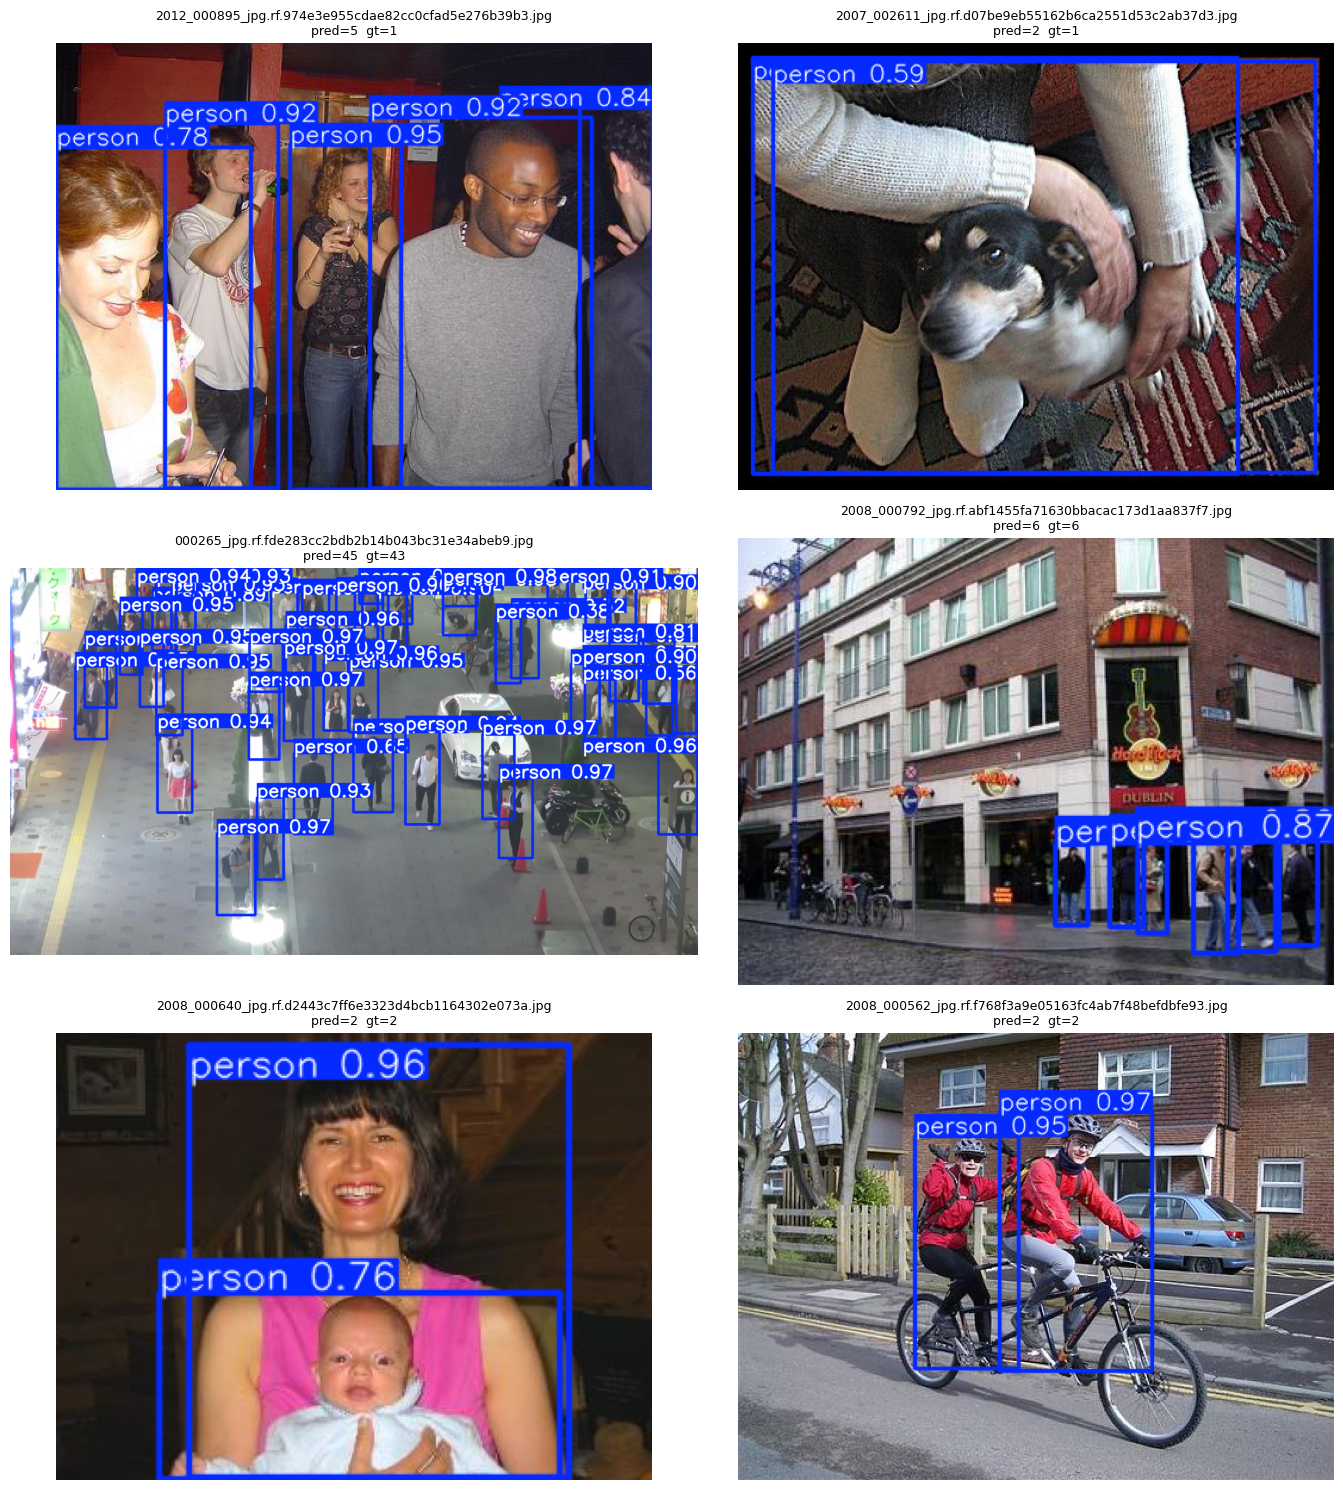

In [9]:
N_SAMPLES = 6
test_dir = PROC_DATASET_DIR / "test" / "images"
test_images: list[Path] = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    test_images.extend(sorted(test_dir.glob(ext)))

samples = random.Random(SEED).sample(test_images, min(N_SAMPLES, len(test_images)))

cols = 2
rows_n = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(14, 5 * rows_n))
axes = axes.flatten()
for ax, img_path in zip(axes, samples):
    r = eval_model.predict(str(img_path), conf=COUNT_CONF, imgsz=COUNT_IMGSZ, verbose=False)[0]
    n = len(r.boxes) if r.boxes is not None else 0
    gt = count_gt(img_path.parent.parent / "labels" / f"{img_path.stem}.txt")
    ax.imshow(r.plot()[..., ::-1])
    ax.set_title(f"{img_path.name}\npred={n}  gt={gt}", fontsize=9)
    ax.axis("off")
for ax in axes[len(samples):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Simpan Artifact

Persist hasil evaluasi counting ke `research/artifacts/people_counting/`:

- `eval_report.json` — config training/eval + metrik agregat (MAE/RMSE/exact/within-1/bias)
- `eval_details.csv` — per-image: gt_count, pred_count, error, abs_error, split

Idempotent — bisa di-rerun kapan aja, file ke-overwrite. Penting: pakai `best.pt` dari run, bukan base pretrained — dan eval di val+test, bukan train.

In [ ]:
import json
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

eval_report = {
    "model_key":   "people_counting",
    "base_weight": str(BASE_MODEL),
    "run_dir":     str(run_dir),
    "best_pt":     str(best_pt),
    "data_yaml":   str(DATA_YAML),
    "class_names": ["person"],
    "seed":        SEED,
    "train_cfg":   TRAIN_CFG,
    "eval_cfg": {
        "conf":       COUNT_CONF,
        "imgsz":      COUNT_IMGSZ,
        "max_images": MAX_IMAGES,
        "splits":     ["test", "valid"],
    },
    "device":  device,
    "metrics": count_metrics,
}

eval_report_path = ARTIFACTS_DIR / "eval_report.json"
eval_report_path.write_text(json.dumps(eval_report, indent=2), encoding="utf-8")
print("Saved:", eval_report_path)

details_path = ARTIFACTS_DIR / "eval_details.csv"
count_df.to_csv(details_path, index=False)
print("Saved:", details_path)


## Catatan

Patokan kasar buat people counting:

| Metric | Bagus | Lumayan | Jelek |
|---|---|---|---|
| MAE | < 1 | 1 – 3 | > 3 |
| Within-1 | > 90% | 80 – 90% | < 80% |
| \|Bias\| | < 0.5 | 0.5 – 1 | > 1 (sistematis salah) |

Object detector (kayak YOLO ini) biasanya kuat di crowd sepi (≤ 10 orang), drop di padat karena occlusion. Kalau target use case-nya emang crowd padat:

- Coba crowd counting model dedicated (CSRNet, P2PNet) yang regress density map, bukan deteksi objek.
- Atau tambah data dari source crowd padat (CrowdHuman, ShanghaiTech).

Buat register ke service: edit entry `people_counting` di [registry.py](../../../src/cctv_insight_ai/models/registry.py).
